# CatBoost (L1, L2, L3)

**Features:** constantes vitales de triage + acuity (ESI) + n_medications (medrecon) + chiefcomplaint (categórica nativa CatBoost)
**Targets:** L1 (ingreso hospitalario), L2 (resultado crítico), L3 (intervención crítica)
**Split:** temporal — sin imputación ni escalado (CatBoost los gestiona de forma nativa)

CatBoost es el modelo de referencia para datos tabulares con features categóricas de alta cardinalidad. Su gestión nativa de missing values y de la codificación ordered target encoding elimina la necesidad de un preprocesamiento externo, reduciendo el riesgo de data leakage.

## 1. Setup y librerías

Importaciones y configuración de estilo gráfico. La dependencia principal es `catboost`, que gestiona de forma nativa el missing value imputation y la codificación ordered target encoding de features categóricas.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 2. Carga de datos

Se cargan las particiones de train y validación generadas por el pipeline de split temporal. CatBoost gestiona de forma nativa los missing values, por lo que no se aplica imputación externa.

In [2]:
load_dotenv(dotenv_path=Path("../../.env"), override=True)
if not os.getenv("MIMIC_IV_ED_PATH"):
    load_dotenv(dotenv_path=Path(".env"), override=True)

DATA          = Path(os.getenv("MIMIC_IV_ED_PATH", ""))
PROCESSED_DIR = Path("../../data/processed")

print(f"DATA         : {DATA}  |  existe: {DATA.exists()}")
print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")

DATA         : C:\Users\cuent\Documents\UAX\TFM\TFM\data  |  existe: True
PROCESSED_DIR: C:\Users\cuent\Documents\UAX\TFM\TFM\data\processed


In [3]:
print("Cargando particiones temporales...")
df_train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
df_val   = pd.read_parquet(PROCESSED_DIR / "val.parquet")

print(f"Train : {df_train.shape[0]:,} pacientes, {df_train.shape[1]} columnas")
print(f"Val   : {df_val.shape[0]:,} pacientes, {df_val.shape[1]} columnas")

Cargando particiones temporales...
Train : 278,320 pacientes, 21 columnas
Val   : 59,640 pacientes, 21 columnas


## 3. Ingeniería de características

### 3a. medrecon → n_medications (proxy de polifarmacia)

In [ ]:
print("Cargando medrecon...")
df_medrecon = pd.read_csv(DATA / "medrecon.csv", low_memory=False)
print(f"medrecon shape: {df_medrecon.shape}")

# Agregación: número de medicamentos previos por estancia
n_meds = (
    df_medrecon.groupby("stay_id")
    .size()
    .rename("n_medications")
    .reset_index()
)

# Left join sobre train y val; estancias sin medrecon reciben 0 medicamentos
df_train = df_train.merge(n_meds, on="stay_id", how="left")
df_val   = df_val.merge(n_meds, on="stay_id", how="left")
df_train["n_medications"] = df_train["n_medications"].fillna(0).astype(int)
df_val["n_medications"]   = df_val["n_medications"].fillna(0).astype(int)

print(f"\nn_medications — train: media={df_train['n_medications'].mean():.2f}, mediana={df_train['n_medications'].median():.0f}")
print(f"Estancias sin medicación previa (train): {(df_train['n_medications']==0).sum():,} ({(df_train['n_medications']==0).mean()*100:.1f}%)")

### 3b. chiefcomplaint — feature categórica (gestionada nativamente por CatBoost)

CatBoost requiere strings no nulos para sus features categóricas. Se imputan los NaN con cadena vacía y se normaliza el texto (minúsculas, strip) para reducir la cardinalidad efectiva del vocabulario.

In [ ]:
# CatBoost requiere strings sin NaN para features categóricas
for df in [df_train, df_val]:
    df["chiefcomplaint"]   = df["chiefcomplaint"].fillna("").astype(str).str.lower().str.strip()
    df["arrival_transport"] = df["arrival_transport"].fillna("desconocido").astype(str).str.lower().str.strip()

print(f"chiefcomplaint — valores únicos en train: {df_train['chiefcomplaint'].nunique():,}")
print(f"arrival_transport — valores únicos en train: {df_train['arrival_transport'].nunique():,}")
print("Distribución arrival_transport (train):")
print(df_train["arrival_transport"].value_counts())

### 3c. Definición del conjunto de features

Se construyen `X_train` y `X_val` con las 9 features seleccionadas (8 numéricas + `chiefcomplaint`). El índice de la feature categórica se pasa a CatBoost para activar el ordered target encoding.

In [ ]:
NUMERIC_FEATURES = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "acuity", "n_medications", "pain"]
CAT_FEATURES     = ["chiefcomplaint", "arrival_transport"]
ALL_FEATURES     = NUMERIC_FEATURES + CAT_FEATURES

# Índices de las features categóricas dentro de ALL_FEATURES
CAT_INDICES = [ALL_FEATURES.index(f) for f in CAT_FEATURES]

TARGETS = ["L1", "L2", "L3"]
TARGET_NAMES = {
    "L1": "Ingreso hospitalario",
    "L2": "Resultado crítico en urgencias",
    "L3": "Intervención crítica en urgencias",
}

X_train = df_train[ALL_FEATURES]
X_val   = df_val[ALL_FEATURES]

print(f"Features totales: {len(ALL_FEATURES)} ({len(NUMERIC_FEATURES)} numéricas + {len(CAT_FEATURES)} categóricas)")
print(f"Categóricas en índices: {CAT_INDICES}")

## 4. Entrenamiento multi-label: L1, L2, L3

Se entrena un clasificador independiente por target. El `scale_pos_weight` compensa el desbalance de clases de forma equivalente a `class_weight='balanced'` en scikit-learn. Se emplea early stopping sobre la métrica AUC en validación para evitar sobreajuste.

In [ ]:
results = {}
models  = {}

for target in TARGETS:
    y_train_t = df_train[target]
    y_val_t   = df_val[target]
    prevalencia = y_train_t.mean() * 100

    # scale_pos_weight equivalente a class_weight='balanced'
    pos_weight = (len(y_train_t) - y_train_t.sum()) / y_train_t.sum()

    print(f"\n{'='*60}")
    print(f"TARGET: {target} — {TARGET_NAMES[target]}")
    print(f"Prevalencia train: {prevalencia:.2f}%  |  scale_pos_weight: {pos_weight:.2f}")
    print(f"{'='*60}")

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        scale_pos_weight=pos_weight,
        eval_metric="AUC",
        cat_features=CAT_INDICES,
        random_seed=42,
        verbose=100,
    )
    model.fit(
        X_train, y_train_t,
        eval_set=(X_val, y_val_t),
        early_stopping_rounds=50,
    )

    y_pred = model.predict_proba(X_val)[:, 1]

    auroc = roc_auc_score(y_val_t, y_pred)
    auprc = average_precision_score(y_val_t, y_pred)
    brier = brier_score_loss(y_val_t, y_pred)

    print(f"\nAUROC : {auroc:.4f}")
    print(f"AUPRC : {auprc:.4f}  (azar: {y_val_t.mean():.4f})")
    print(f"Brier : {brier:.4f}")

    results[target] = {"AUROC": auroc, "AUPRC": auprc, "Brier": brier, "Prev_val": y_val_t.mean()}
    models[target]  = model

print("\nEntrenamiento completado para L1, L2 y L3.")

## 5. Tabla comparativa de resultados

CatBoost mejora sustancialmente el AUPRC de L2 y L3 respecto al baseline LogReg (×15 y ×18 sobre el azar), gracias a la capacidad del modelo de capturar interacciones no lineales y a la codificación nativa de `chiefcomplaint` con alta cardinalidad.

In [8]:
df_results = pd.DataFrame(results).T
df_results.index.name = "Target"
df_results["AUPRC_lift"] = (df_results["AUPRC"] / df_results["Prev_val"]).round(2)

print("=== CatBoost — Resultados en Validación ===")
print(df_results.round(4).to_string())
print("\n(AUPRC_lift = AUPRC / prevalencia — cuánto supera al azar)")

=== CatBoost — Resultados en Validación ===
         AUROC   AUPRC   Brier  Prev_val  AUPRC_lift
Target                                              
L1      0.8316  0.7526  0.1684    0.3831        1.96
L2      0.8775  0.2257  0.1363    0.0147       15.37
L3      0.8941  0.1144  0.1072    0.0061       18.90

(AUPRC_lift = AUPRC / prevalencia — cuánto supera al azar)


## 6. Importancia de variables por target

Importancia de permutación nativa de CatBoost (PredictionValuesChange): indica el incremento relativo en el error al permutar cada variable. Permite identificar qué features dominan la predicción en cada target.

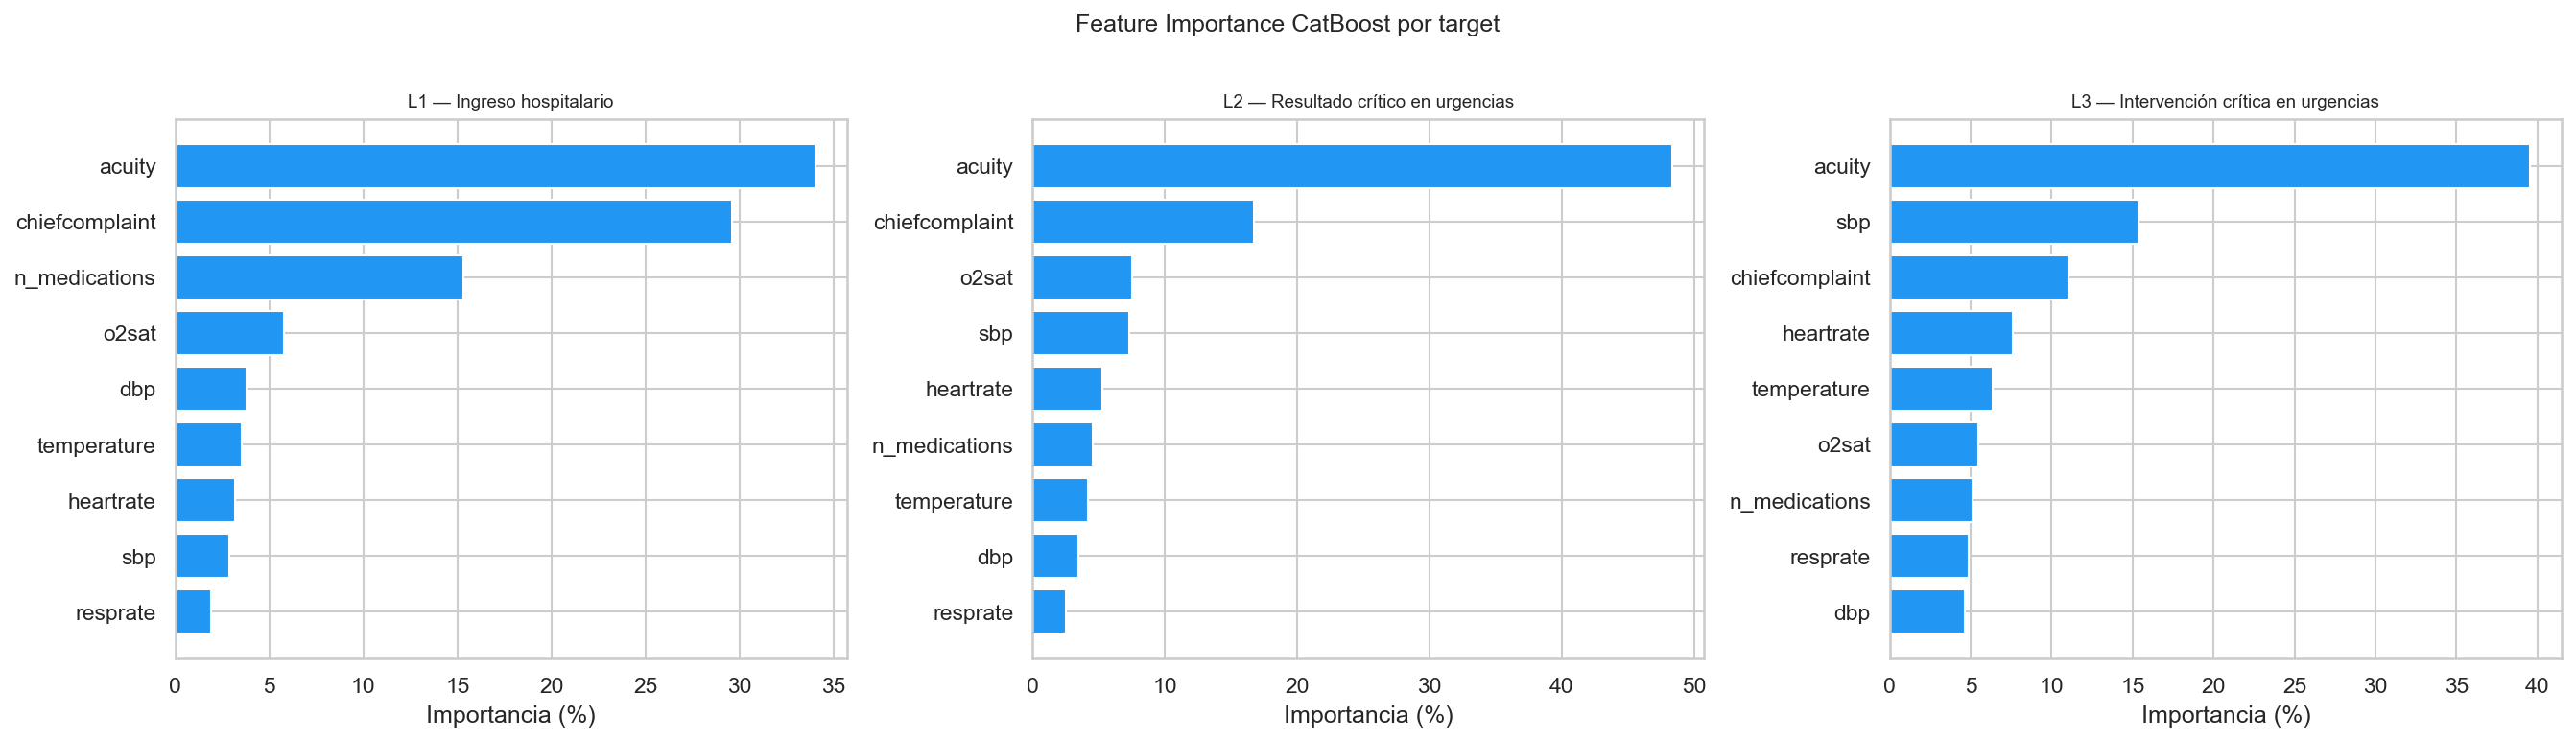

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, TARGETS):
    importances = models[target].get_feature_importance()
    df_imp = (
        pd.DataFrame({"feature": ALL_FEATURES, "importance": importances})
        .sort_values("importance", ascending=True)
    )
    ax.barh(df_imp["feature"], df_imp["importance"], color="#2196F3")
    ax.set_title(f"{target} — {TARGET_NAMES[target]}", fontsize=9)
    ax.set_xlabel("Importancia (%)")

plt.suptitle("Feature Importance CatBoost por target", y=1.02)
plt.tight_layout()
plt.show()

## 7. Comparativa LogReg vs CatBoost

Contraste directo de las métricas de discriminación (AUROC, AUPRC) y calibración (Brier) entre el modelo lineal de referencia y CatBoost sobre el mismo conjunto de validación.

In [ ]:
# Resultados previos de LogReg (notebook 01)
logreg_results = {
    "L1": {"AUROC": 0.8048, "AUPRC": 0.7102, "Brier": 0.1812},
    "L2": {"AUROC": 0.8617, "AUPRC": 0.0962, "Brier": 0.1596},
    "L3": {"AUROC": 0.8773, "AUPRC": 0.0705, "Brier": 0.1383},
}

rows = []
for target in TARGETS:
    lr = logreg_results[target]
    cb = results[target]
    rows.append({
        "Target": target,
        "LogReg_AUROC": lr["AUROC"],
        "CatBoost_AUROC": cb["AUROC"],
        "LogReg_AUPRC": lr["AUPRC"],
        "CatBoost_AUPRC": cb["AUPRC"],
        "LogReg_Brier": lr["Brier"],
        "CatBoost_Brier": cb["Brier"],
    })

df_comp = pd.DataFrame(rows).set_index("Target")
print("=== Comparativa LogReg vs CatBoost ===")
print(df_comp.round(4).to_string())